# Análisis no supervisado en el dataset Spotify

* Objetivo

El objetivo de este notebook es el de encontrar patrones o grupos ocultos utilizando herramientas de clustering para luego realizar análisis de estos hallazgos para los futuros modelos de ML.

En esta etapa se realizan las siguientes operaciones:

* Matriz de correlación
* PCA

In [70]:
import pandas as pd
import numpy as np
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [ ]:
data = pd.read_csv("../dataset/spotify_train_preprocesado.csv")

df = data.copy()

df.head()

,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,1
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,2
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,2


# 1ra pregunta: ¿Qué perfiles o tipos de canciones se pueden identificar según sus características musicales?

Primero, se realizará un chequeo de las correlaciones para lograr identificar si existen correlaciones fuertes en el dataset en base a las características de las canciones.

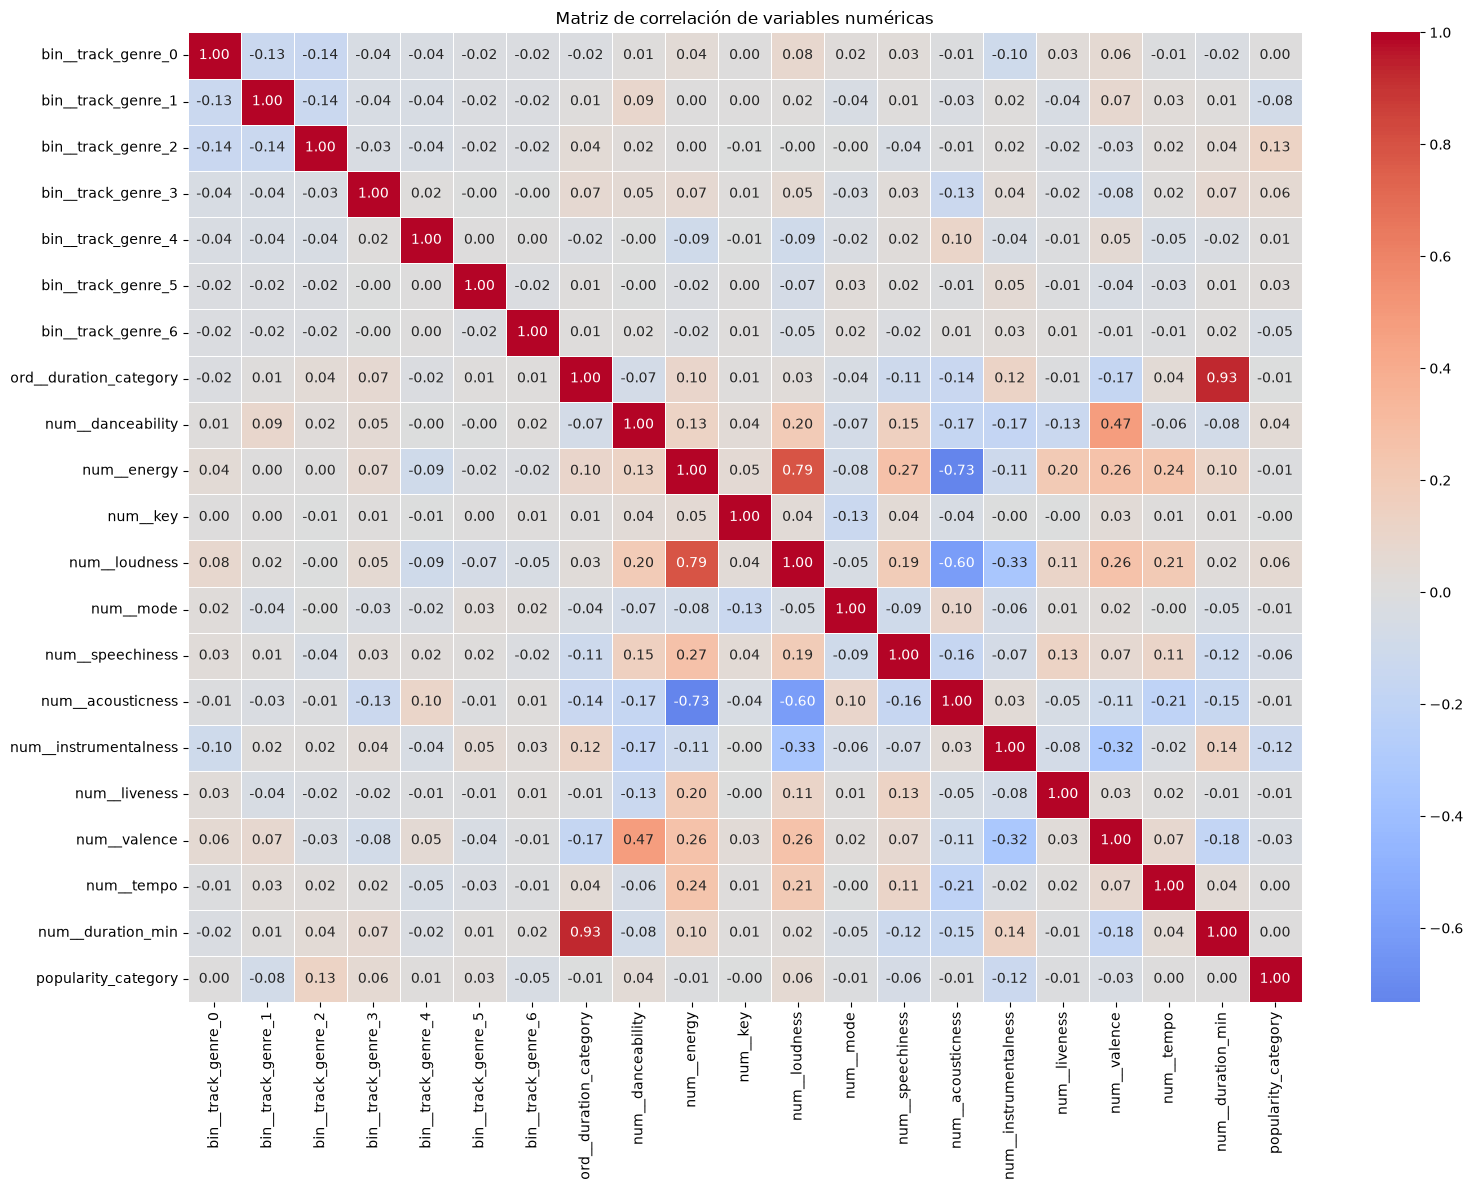

In [ ]:
# Calcular matriz de correlación
matriz_correlacion = df.corr()

# Visualizar matriz
plt.figure(figsize=(16, 12))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

---

# PCA en el dataset

Con el fin de entender la importancia de las variables del dataset y reducir la dimensionalidad, se utiliza la herramienta PCA para identificar la varianza explicada por cada componente individual y la acumulada del PCA.

In [ ]:
features_pca = [
    "bin__track_genre_0",
    "bin__track_genre_1",
    "bin__track_genre_2",
    "bin__track_genre_3",
    "bin__track_genre_4",
    "bin__track_genre_5",
    "bin__track_genre_6",
    "ord__duration_category",
    "num__danceability",
    "num__energy",
    "num__key",
    "num__loudness",
    "num__mode",
    "num__speechiness",
    "num__acousticness",
    "num__instrumentalness",
    "num__liveness",
    "num__valence",
    "num__tempo",
    "num__duration_min"
]

X_pca = df[features_pca]

In [ ]:
pca = PCA()

X_pca_transformed = pca.fit_transform(X_pca)

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, (individual, cumulative) in enumerate(
    zip(explained_variance, cumulative_variance),
    start=1
):
    print(
        f"PC{i}: "
        f"{individual:.2%} individual | "
        f"{cumulative:.2%} acumulada"
    )

PC1: 19.70% individual | 19.70% acumulada
PC2: 14.80% individual | 34.50% acumulada
PC3: 9.03% individual | 43.53% acumulada
PC4: 8.04% individual | 51.57% acumulada
PC5: 6.95% individual | 58.52% acumulada
PC6: 6.36% individual | 64.89% acumulada
PC7: 6.00% individual | 70.89% acumulada
PC8: 5.55% individual | 76.43% acumulada
PC9: 5.15% individual | 81.59% acumulada
PC10: 3.19% individual | 84.78% acumulada
PC11: 2.28% individual | 87.06% acumulada
PC12: 1.89% individual | 88.95% acumulada
PC13: 1.85% individual | 90.81% acumulada
PC14: 1.74% individual | 92.55% acumulada
PC15: 1.71% individual | 94.25% acumulada
PC16: 1.64% individual | 95.89% acumulada
PC17: 1.55% individual | 97.44% acumulada
PC18: 1.16% individual | 98.59% acumulada
PC19: 0.93% individual | 99.53% acumulada
PC20: 0.47% individual | 100.00% acumulada


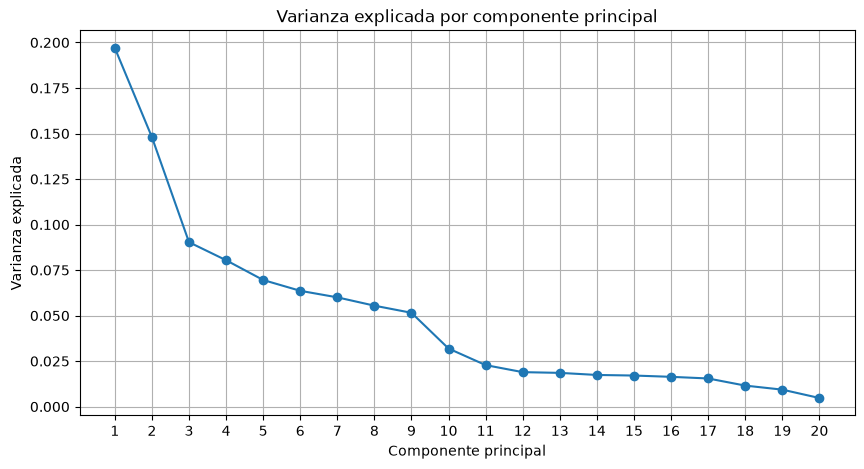

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Componente principal")
plt.ylabel("Varianza explicada")
plt.title("Varianza explicada por componente principal")
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)

plt.show()

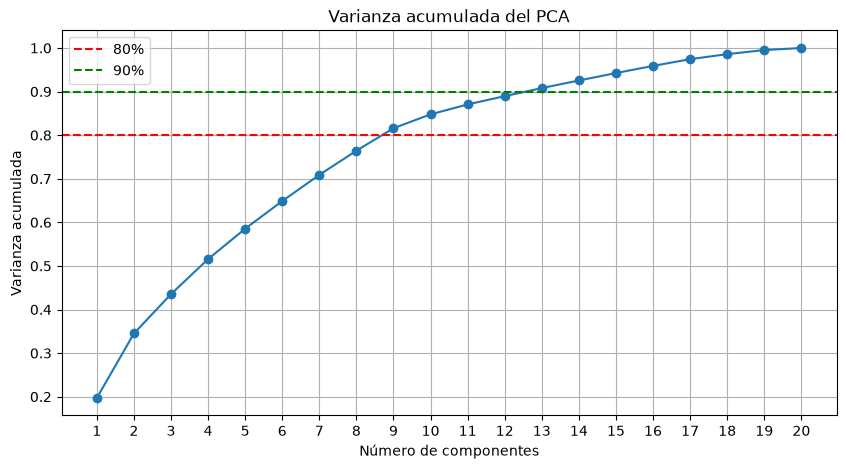

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.80,
    color="red",
    linestyle="--",
    label="80%"
)

plt.axhline(
    0.90,
    color="green",
    linestyle="--",
    label="90%"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada del PCA")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.grid(True)

plt.show()

# Selección de componentes PCA

Con el fin de seleccionar el número de componentes adecuado y **corroborar su impacto en el análisis**, se utilizarán dos dataframes con distinta cantidad de componentes los cuales se componenen de la siguiente manera:

Dataframe 1:
* Número de componentes: 9 
* Varianza acumulada: 81,59%
* Representación de datos: 45%

Dataframe 2:
* Número de componentes: 13 
* Varianza acumulada: 90,81%
* Representación de datos: 65%

In [ ]:
pca1 = PCA(n_components = 9)

pca2 = PCA(n_components = 13)

X_pca_df1 = pca1.fit_transform(X_pca)

X_pca_df2 = pca2.fit_transform(X_pca)

Creación del Dataframe con los componentes

In [ ]:
df_pca_1 = pd.DataFrame(
    X_pca_df1,
    columns=[f"PC{i}" for i in range(1, pca1.n_components_ + 1)],
    index=df.index
)

df_pca_1["popularity_category"] = df["popularity_category"]


df_pca_2 = pd.DataFrame(
    X_pca_df2,
    columns=[f"PC{i}" for i in range(1, pca2.n_components_ + 1)],
    index=df.index
)

df_pca_2["popularity_category"] = df["popularity_category"]

In [ ]:
df_pca_1.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,popularity_category
0,-0.200809,-1.375739,1.229657,0.260928,0.175410,1.301302,-0.213395,0.526588,0.631094,1
1,-0.070853,-0.885718,0.933779,0.659522,-0.334985,1.296782,0.063861,0.117424,0.242782,0
2,-0.143451,1.765934,-0.788070,0.426808,-0.482869,1.772724,-0.813168,0.414526,-1.460656,2
3,1.108933,-0.815601,0.887455,-1.884844,-0.158095,0.821274,-0.896440,-0.363621,-0.273614,0
4,-2.034280,-1.121345,0.131627,-1.367931,-1.711352,-0.524165,3.779628,-1.182260,1.592352,2


In [ ]:
df_pca_2.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,popularity_category
0,-0.200809,-1.375739,1.229657,0.260928,0.175410,1.301302,-0.213395,0.526588,0.631094,0.585176,-0.144823,0.062624,-0.054573,1
1,-0.070853,-0.885718,0.933779,0.659522,-0.334985,1.296782,0.063861,0.117424,0.242782,0.571305,0.086036,0.044179,-0.056428,0
2,-0.143451,1.765934,-0.788070,0.426808,-0.482869,1.772724,-0.813168,0.414526,-1.460656,0.259746,-0.392587,-0.103014,-0.101921,2
3,1.108933,-0.815601,0.887455,-1.884844,-0.158095,0.821274,-0.896440,-0.363621,-0.273614,-1.327553,0.229204,0.035569,-0.013113,0
4,-2.034280,-1.121345,0.131627,-1.367931,-1.711352,-0.524165,3.779628,-1.182260,1.592352,0.443039,-0.276758,0.123554,0.287918,2


Comparación de varianza explicada de ambos PCA

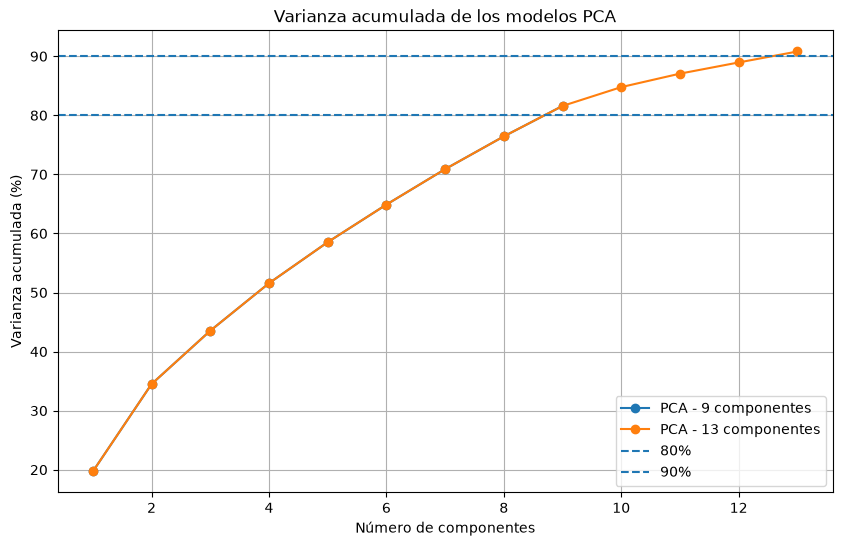

In [ ]:
# PCA de 9 componentes
varianza_9 = pca1.explained_variance_ratio_
acumulada_9 = np.cumsum(varianza_9)

# PCA de 13 componentes
varianza_13 = pca2.explained_variance_ratio_
acumulada_13 = np.cumsum(varianza_13)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 10),
    acumulada_9 * 100,
    marker="o",
    label="PCA - 9 componentes"
)

plt.plot(
    range(1, 14),
    acumulada_13 * 100,
    marker="o",
    label="PCA - 13 componentes"
)

plt.axhline(
    80,
    linestyle="--",
    label="80%"
)

plt.axhline(
    90,
    linestyle="--",
    label="90%"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada (%)")
plt.title("Varianza acumulada de los modelos PCA")
plt.legend()
plt.grid(True)
plt.show()

Análisis de componentes

In [ ]:
loadings = pd.DataFrame(
    pca1.components_.T,
    index=X_pca.columns,
    columns=[f"PC{i}" for i in range(1, 10)]
)

for pc in loadings.columns:
    print(f"\n{pc}")
    print(
        loadings[pc]
        .sort_values(key=abs, ascending=False)
        .head(10)
    )


PC1
num__energy              0.522030
num__loudness            0.506707
num__acousticness       -0.451966
num__valence             0.264886
num__danceability        0.218744
num__speechiness         0.218112
num__instrumentalness   -0.201598
num__tempo               0.192058
num__liveness            0.108866
num__mode               -0.071653
Name: PC1, dtype: float64

PC2
num__duration_min         0.616080
ord__duration_category    0.609547
num__valence             -0.291562
num__instrumentalness     0.235927
num__danceability        -0.205429
num__acousticness        -0.170091
num__speechiness         -0.114689
num__energy               0.105205
num__tempo                0.074615
num__mode                -0.067027
Name: PC2, dtype: float64

PC3
num__danceability         0.567084
num__valence              0.423668
num__liveness            -0.395679
ord__duration_category    0.266096
num__duration_min         0.256708
num__tempo               -0.237581
num__speechiness         -0.22653

In [ ]:
df_muestra, _ = train_test_split(
    df_pca_1,
    train_size=5000,
    stratify=df_pca_1["popularity_category"],
    random_state=42
)

In [ ]:
pca3 = PCA(n_components=3)

X_pca_df3 = pca3.fit_transform(X_pca)

print("Varianza explicada:")
for i, varianza in enumerate(pca3.explained_variance_ratio_, start=1):
    print(f"PC{i}: {varianza:.2%}")

print(f"\nVarianza acumulada: {pca3.explained_variance_ratio_.sum():.2%}")

Varianza explicada:
PC1: 19.70%
PC2: 14.80%
PC3: 9.03%

Varianza acumulada: 43.53%


In [ ]:
df_pca_3 = pd.DataFrame(
    X_pca_df3,
    columns=[f"PC{i}" for i in range(1, pca3.n_components_ + 1)],
    index=df.index
)

df_pca_3["popularity_category"] = df["popularity_category"]

In [ ]:
df_pca_3.head()

,PC1,PC2,PC3,popularity_category
0,-0.200809,-1.375739,1.229657,1
1,-0.070853,-0.885718,0.933779,0
2,-0.143451,1.765934,-0.788070,2
3,1.108933,-0.815601,0.887455,0
4,-2.034280,-1.121345,0.131627,2


In [ ]:
df_muestra_3, _ = train_test_split(
    df_pca_3,
    train_size=5000,
    stratify=df_pca_3["popularity_category"],
    random_state=42
)

print(f"Canciones seleccionadas: {len(df_muestra_3)}")

Canciones seleccionadas: 5000


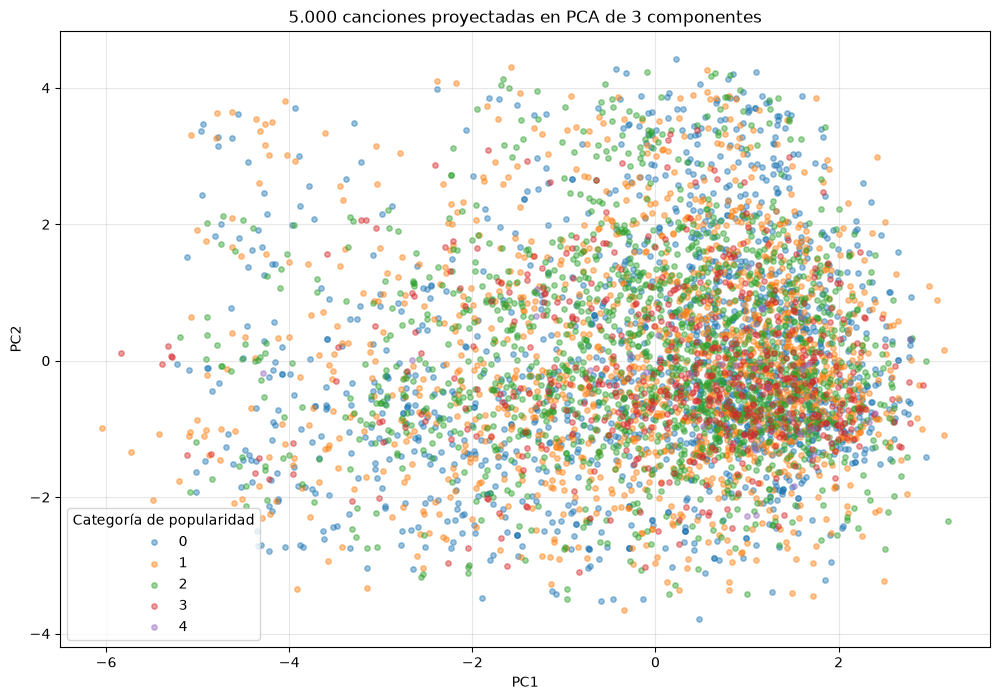

In [ ]:
plt.figure(figsize=(12, 8))

for categoria in sorted(df_muestra_3["popularity_category"].unique()):

    datos = df_muestra_3[
        df_muestra_3["popularity_category"] == categoria
    ]

    plt.scatter(
        datos["PC1"],
        datos["PC2"],
        alpha=0.45,
        s=15,
        label=categoria
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("5.000 canciones proyectadas en PCA de 2 componentes")
plt.legend(title="Categoría de popularidad")
plt.grid(True, alpha=0.3)
plt.show()

# Graficación en tres dimensiones de PCA 3

In [65]:
fig = px.scatter_3d(
    df_muestra_3,
    x="PC1",
    y="PC2",
    z="PC3",
    color="popularity_category",

    hover_data={
        "PC1": ":.3f",
        "PC2": ":.3f",
        "PC3": ":.3f",
        "popularity_category": True
    },

    title="PCA de 3 componentes — 5.000 canciones",

    labels={
        "PC1": "Componente Principal 1",
        "PC2": "Componente Principal 2",
        "PC3": "Componente Principal 3",
        "popularity_category": "Popularidad"
    },

    opacity=0.6
)

fig.update_traces(
    marker=dict(size=3)
)

fig.update_layout(
    width=1000,
    height=800
)

fig.show()

In [68]:
df_muestra_pca_1, _ = train_test_split(
    df_pca_1,
    train_size=5000,
    stratify=df_pca_1["popularity_category"],
    random_state=42
)

fig = px.scatter_3d(
    df_muestra_pca_1,
    x="PC1",
    y="PC2",
    z="PC3",
    color="popularity_category",
    hover_data={
        "PC1": ":.3f",
        "PC2": ":.3f",
        "PC3": ":.3f",
        "PC4": ":.3f",
        "PC5": ":.3f",
        "PC6": ":.3f",
        "PC7": ":.3f",
        "PC8": ":.3f",
        "PC9": ":.3f",
        "popularity_category": True
    },
    title="PCA de 9 componentes — Proyección 3D según popularidad",
    labels={
        "PC1": "Componente Principal 1",
        "PC2": "Componente Principal 2",
        "PC3": "Componente Principal 3",
        "popularity_category": "Popularidad"
    },
    opacity=0.6
)

fig.update_traces(
    marker=dict(size=3)
)

fig.update_layout(
    width=1000,
    height=800
)

fig.show()

In [69]:
df_muestra_pca_2, _ = train_test_split(
    df_pca_2,
    train_size=5000,
    stratify=df_pca_1["popularity_category"],
    random_state=42
)

fig = px.scatter_3d(
    df_muestra_pca_2,
    x="PC1",
    y="PC2",
    z="PC3",
    color="popularity_category",
    hover_data={
        "PC1": ":.3f",
        "PC2": ":.3f",
        "PC3": ":.3f",
        "PC4": ":.3f",
        "PC5": ":.3f",
        "PC6": ":.3f",
        "PC7": ":.3f",
        "PC8": ":.3f",
        "PC9": ":.3f",
        "PC10": ":.3f",
        "PC11": ":.3f",
        "PC12": ":.3f",
        "PC13": ":.3f",
        "popularity_category": True
    },
    title="PCA de 13 componentes — Proyección 3D según popularidad",
    labels={
        "PC1": "Componente Principal 1",
        "PC2": "Componente Principal 2",
        "PC3": "Componente Principal 3",
        "popularity_category": "Popularidad"
    },
    opacity=0.6
)

fig.update_traces(
    marker=dict(size=3)
)

fig.update_layout(
    width=1000,
    height=800
)

fig.show()

---

# Proceso de K-means y Clusters

Buscando el número adecuado de clusters

In [72]:
# 9 Dimensiones
X_cluster_1 = df_pca_1.drop(columns="popularity_category")

# 13 Dimensiones
X_cluster_2 = df_pca_2.drop(columns="popularity_category")

# 3 Dimensiones
X_cluster_3 = df_pca_3.drop(columns="popularity_category")

In [ ]:
""" 
La línea de código es muy pesada computacionalmente, por lo qué se deberá realizar el análisis
a través de un muestreo estratificado.
"""

inercia = []
silhouette = []

rango_k = range(2, 9)

for k in rango_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    etiquetas = kmeans.fit_predict(X_cluster_1)
    
    inercia.append(kmeans.inertia_)
    silhouette.append(
        silhouette_score(X_cluster_1, etiquetas)
    )

KeyboardInterrupt: 

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_pca_1["cluster"] = kmeans.fit_predict(X_cluster_1)



X_cluster_2 = df_pca_2.drop(columns="popularity_category")

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_pca_2["cluster"] = kmeans.fit_predict(X_cluster_2)



X_cluster_3 = df_pca_3.drop(columns="popularity_category")

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_pca_3["cluster"] = kmeans.fit_predict(X_cluster_3)

In [ ]:
df_pca_1.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,popularity_category,cluster
0,-0.200809,-1.375739,1.229657,0.260928,0.175410,1.301302,-0.213395,0.526588,0.631094,1,2
1,-0.070853,-0.885718,0.933779,0.659522,-0.334985,1.296782,0.063861,0.117424,0.242782,0,2
2,-0.143451,1.765934,-0.788070,0.426808,-0.482869,1.772724,-0.813168,0.414526,-1.460656,2,1
3,1.108933,-0.815601,0.887455,-1.884844,-0.158095,0.821274,-0.896440,-0.363621,-0.273614,0,3
4,-2.034280,-1.121345,0.131627,-1.367931,-1.711352,-0.524165,3.779628,-1.182260,1.592352,2,0
